In [2]:
%matplotlib inline
# Cell 1 — WO19: setup, imports, city selection via whc_pca_coords + k-means k=50
#
# Load signature-PCA coordinates for all 258 WHC members from whc_pca_coords;
# run k-means at k=50 (random_state=42); pin WO18's 9 WHC + Kaifeng in their
# clusters; pick centroid-nearest WHC city for each unoccupied cluster.
# Output: FIXTURES list (~50 entries), LEVEL, BANDS_AE, SHARP_THR.

import sys, math, time, warnings
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from IPython.display import Image as IPImage, display
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SKPCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr, chi2_contingency

sys.path.insert(0, '../../../..')
from scripts.shared.db_utils import db_connect
import scripts.shared.db_utils as _dbu
from scripts.edop.areas.engine import single_basin_signature

ROOT = Path(_dbu.__file__).parent.parent.parent
OUT  = ROOT / 'output' / 'edop' / 'areas'
OUT.mkdir(parents=True, exist_ok=True)

conn = db_connect()
print('Connected:', conn.execute('SELECT current_database()').fetchone()[0])

# WO18-fixed: always included, never re-selected
WO18_FIXED = [
    {'name': 'Timbuktu',      'lat':  16.8167, 'lon':  -2.9833, 'whc': True,  'wo18': True},
    {'name': 'Kaifeng',       'lat':  34.7972, 'lon': 114.3069, 'whc': False, 'wo18': True},
    {'name': 'Córdoba',       'lat':  37.8916, 'lon':  -4.7728, 'whc': True,  'wo18': True},
    {'name': 'Kraków',        'lat':  50.0614, 'lon':  19.9372, 'whc': True,  'wo18': True},
    {'name': 'Tallinn',       'lat':  59.4372, 'lon':  24.7450, 'whc': True,  'wo18': True},
    {'name': 'Bergen',        'lat':  60.3925, 'lon':   5.3233, 'whc': True,  'wo18': True},
    {'name': 'Luang Prabang', 'lat':  19.8931, 'lon': 102.1381, 'whc': True,  'wo18': True},
    {'name': 'Panama City',   'lat':   9.0000, 'lon': -79.5000, 'whc': True,  'wo18': True},
    {'name': 'Brasília',      'lat': -15.7939, 'lon': -47.8828, 'whc': True,  'wo18': True},
    {'name': 'Guanajuato',    'lat':  21.0178, 'lon':-101.2567, 'whc': True,  'wo18': True},
]
WO18_WHC_NAMES = {fx['name'] for fx in WO18_FIXED if fx['whc']}

# Load PCA coords for all 258 WHC members (workbench-computed, signature PCA)
pca_df = pd.read_sql("""
    SELECT w.id, w.city, w.country, w.region,
           ST_Y(w.geom) AS lat, ST_X(w.geom) AS lon,
           p.*
    FROM gaz.wh_cities w
    JOIN whc_pca_coords p ON p.city_id = w.id
    ORDER BY w.city
""", conn)
pc_cols = [c for c in pca_df.columns if c.startswith('pc')]
print(f'Loaded {len(pca_df)} WHC cities  |  PC columns ({len(pc_cols)}): {pc_cols}')

# k-means k=50 in signature-PCA space
X_sig = pca_df[pc_cols].values
km50  = KMeans(n_clusters=50, random_state=42, n_init=20)
pca_df['km50'] = km50.fit_predict(X_sig)

# Pin WO18 WHC cities; record which clusters they occupy
occupied = {}   # cluster_id (int) → fixture dict
for _, row in pca_df[pca_df['city'].isin(WO18_WHC_NAMES)].iterrows():
    cid = int(row['km50'])
    fx  = next(f for f in WO18_FIXED if f['name'] == row['city'])
    occupied[cid] = {**fx, 'cluster': cid, 'country': row['country'], 'region': row['region']}

missing = WO18_WHC_NAMES - set(r['name'] for r in occupied.values())
if missing:
    print(f'WARNING — WO18 cities not found in whc_pca_coords: {missing}')
print(f'WO18 WHC cities occupy {len(occupied)} of 50 k-means clusters.')

# Fill unoccupied clusters with centroid-nearest WHC city
centroids = km50.cluster_centers_
for cid in range(50):
    if cid in occupied:
        continue
    members = pca_df[pca_df['km50'] == cid]
    X_m    = members[pc_cols].values
    dists  = np.linalg.norm(X_m - centroids[cid], axis=1)
    best   = members.iloc[dists.argmin()]
    occupied[cid] = {
        'name': best['city'], 'lat': float(best['lat']), 'lon': float(best['lon']),
        'country': best['country'], 'region': best['region'],
        'cluster': cid, 'whc': True, 'wo18': False,
    }

# Append Kaifeng (non-WHC, standing fixture)
kf = next(f for f in WO18_FIXED if f['name'] == 'Kaifeng')
occupied['kf'] = {**kf, 'country': 'China', 'region': 'Asia and the Pacific', 'cluster': None}

FIXTURES  = sorted(occupied.values(), key=lambda f: f['name'])
LEVEL     = '06'
BANDS_AE  = ['A', 'B', 'C', 'D', 'E']
SHARP_THR = 10.0

n_new  = sum(1 for f in FIXTURES if not f.get('wo18'))
n_wo18 = sum(1 for f in FIXTURES if f.get('wo18'))
print(f'\n{len(FIXTURES)} fixtures total — {n_wo18} from WO18 (incl. Kaifeng), {n_new} new WHC cities')
print()
for fx in FIXTURES:
    tag  = '[WO18]' if fx.get('wo18') else '[new ]'
    cstr = str(fx['cluster']) if fx['cluster'] is not None else 'fixed'
    print(f'  {tag} {fx["name"]:22s}  k50={cstr:<3}  {fx.get("region",""):25s}  ({fx["country"]})')


Connected: cedop
Loaded 254 WHC cities  |  PC columns (50): ['pc1', 'pc2', 'pc3', 'pc4', 'pc5', 'pc6', 'pc7', 'pc8', 'pc9', 'pc10', 'pc11', 'pc12', 'pc13', 'pc14', 'pc15', 'pc16', 'pc17', 'pc18', 'pc19', 'pc20', 'pc21', 'pc22', 'pc23', 'pc24', 'pc25', 'pc26', 'pc27', 'pc28', 'pc29', 'pc30', 'pc31', 'pc32', 'pc33', 'pc34', 'pc35', 'pc36', 'pc37', 'pc38', 'pc39', 'pc40', 'pc41', 'pc42', 'pc43', 'pc44', 'pc45', 'pc46', 'pc47', 'pc48', 'pc49', 'pc50']
WO18 WHC cities occupy 9 of 50 k-means clusters.

51 fixtures total — 10 from WO18 (incl. Kaifeng), 41 new WHC cities

  [new ] Aleppo                  k50=12   Arab states                (Syria)
  [new ] Bam                     k50=6    Asia and the Pacific       (Iran)
  [new ] Belo Horizonte          k50=26   Americas                   (Brazil)
  [new ] Bergama                 k50=31   Asia and the Pacific       (Turkey)
  [WO18] Bergen                  k50=17   Europe                     (Norway)
  [new ] Bolgar                  k50=23   

In [5]:
# Cell 2 — function definitions (verbatim from WO18 Cell 2)
#
# resolve_basin_ring: point → (center_df, ring_gdf) with border_bearing.
#   Uses ST_PointOnSurface for neighbor query points — 3% of L06 basins
#   have centroids outside their polygon; PointOnSurface guarantees containment.
# run_signatures: center + ring → dict hybas_id → {var: score}
# build_transition_table: signed divergence (center − neighbor) per variable
# transition_character: per-variable summary sorted by max_abs

CONTINUOUS_METHODS = {'area_weighted', 'dominant_basin', 'distribution_only', 'extreme'}
META_COLS = ['hybas_id', 'border_bearing', 'centroid_bearing', 'bearing_delta', 'shared_km']


def _bearing(lat1, lon1, lat2, lon2):
    """Great-circle bearing (° true, 0=N clockwise)."""
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dl = math.radians(lon2 - lon1)
    x = math.sin(dl) * math.cos(phi2)
    y = math.cos(phi1) * math.sin(phi2) - math.sin(phi1) * math.cos(phi2) * math.cos(dl)
    return (math.degrees(math.atan2(x, y)) + 360) % 360


def resolve_basin_ring(lat, lon, level, conn):
    """Point → (center_df, ring_gdf) with border_bearing + centroid_bearing."""
    table = f'public.basin{level}'
    row = conn.execute(f"""
        SELECT hybas_id, ST_Y(ST_Centroid(geom)), ST_X(ST_Centroid(geom))
        FROM {table}
        WHERE ST_Contains(geom, ST_SetSRID(ST_MakePoint({lon}, {lat}), 4326))
    """).fetchone()
    center_id, center_lat, center_lon = int(row[0]), float(row[1]), float(row[2])
    center_df = pd.DataFrame({'hybas_id': [center_id], 'weight': [1.0]})
    center_df['hybas_id'] = center_df['hybas_id'].astype('int64')

    ring_sql = f"""
    WITH center AS (SELECT geom FROM {table} WHERE hybas_id = {center_id})
    SELECT b.hybas_id, b.sub_area AS sub_area_km2, b.geom,
           ST_Y(ST_PointOnSurface(b.geom))                    AS neighbor_lat,
           ST_X(ST_PointOnSurface(b.geom))                    AS neighbor_lon,
           ST_Y(ST_Centroid(ST_Intersection(b.geom, c.geom))) AS border_mid_lat,
           ST_X(ST_Centroid(ST_Intersection(b.geom, c.geom))) AS border_mid_lon,
           CASE WHEN ST_Dimension(ST_Intersection(b.geom, c.geom)) = 1
                THEN ROUND((ST_Length(ST_Intersection(b.geom, c.geom)::geography)/1000.0)::numeric, 2)
                ELSE 0.0 END AS shared_km
    FROM {table} b, center c
    WHERE ST_Touches(b.geom, c.geom)
    ORDER BY b.sub_area DESC
    """
    ring_gdf = gpd.read_postgis(ring_sql, conn, geom_col='geom').rename_geometry('geometry')
    ring_gdf['hybas_id'] = ring_gdf['hybas_id'].astype('int64')
    ring_gdf['border_bearing']   = ring_gdf.apply(
        lambda r: _bearing(center_lat, center_lon, r['border_mid_lat'], r['border_mid_lon']), axis=1)
    ring_gdf['centroid_bearing'] = ring_gdf.apply(
        lambda r: _bearing(center_lat, center_lon, r['neighbor_lat'], r['neighbor_lon']), axis=1)
    return center_df, ring_gdf


def run_signatures(center_df, ring_gdf, lat, lon, level_str, conn):
    """Run single_basin_signature for center + each ring neighbor."""
    level_int = int(level_str)
    sigs = {}
    cid = int(center_df['hybas_id'].iloc[0])
    payload = single_basin_signature(lat, lon, conn, level=level_int, bands=BANDS_AE, include_detail=False)
    rows = [r for r in payload['rows'] if r.get('band') != 'T' and r['method'] in CONTINUOUS_METHODS]
    sigs[cid] = {r['variable']: r['representative_score'] for r in rows}
    for _, nb in ring_gdf.iterrows():
        nid = int(nb['hybas_id'])
        p   = single_basin_signature(float(nb['neighbor_lat']), float(nb['neighbor_lon']),
                                      conn, level=level_int, bands=BANDS_AE, include_detail=False)
        rows = [r for r in p['rows'] if r.get('band') != 'T' and r['method'] in CONTINUOUS_METHODS]
        sigs[nid] = {r['variable']: r['representative_score'] for r in rows}
    return sigs


def build_transition_table(center_id, ring_sorted, sigs):
    """Signed divergence table: center_score − neighbor_score per (neighbor, variable)."""
    center_scores = sigs[center_id]
    rows = []
    for _, nb in ring_sorted.iterrows():
        nid = int(nb['hybas_id'])
        nb_scores = sigs.get(nid, {})
        row = {'hybas_id': nid,
               'border_bearing':   round(nb['border_bearing'],   1),
               'centroid_bearing': round(nb['centroid_bearing'], 1),
               'bearing_delta':    round(nb.get('bearing_delta', 0), 1),
               'shared_km':        nb['shared_km']}
        for var, c_score in center_scores.items():
            n_score = nb_scores.get(var)
            row[var] = round(c_score - n_score, 1) if (c_score is not None and n_score is not None) else None
        rows.append(row)
    return pd.DataFrame(rows)


def transition_character(div_df, threshold=10.0):
    """Per-variable character summary sorted by max_abs."""
    var_cols = [c for c in div_df.columns if c not in META_COLS]
    rows = []
    for var in var_cols:
        vals = div_df[var].dropna()
        if vals.empty:
            continue
        abs_vals = vals.abs()
        rows.append({
            'variable':     var,
            'max_abs':      round(abs_vals.max(), 1),
            'mean_abs':     round(abs_vals.mean(), 1),
            'n_sharp':      int((abs_vals >= threshold).sum()),
            'sign_pattern': 'all+' if (vals > 0).all() else ('all-' if (vals < 0).all() else 'mixed'),
        })
    if not rows:
        return pd.DataFrame(columns=['variable', 'max_abs', 'mean_abs', 'n_sharp', 'sign_pattern'])
    return pd.DataFrame(rows).sort_values('max_abs', ascending=False).reset_index(drop=True)


print('Functions defined.')


Functions defined.


In [6]:
# Cell 3 — run resolve_basin_ring + signatures for all ~50 fixtures
#
# Runtime: ~60s per fixture at L06 → expect ~50 min total.
# Progress printed per fixture: name, center_id, ring size, n_sharp, elapsed.
# RESULTS dict: name → {center_df, ring_sorted, sigs, div_df, char_df, center_id, n_ring}

RESULTS = {}

for fx in FIXTURES:
    name    = fx['name']
    lat, lon = fx['lat'], fx['lon']
    t0 = time.time()

    center_df, ring_gdf = resolve_basin_ring(lat, lon, LEVEL, conn)
    center_id = int(center_df['hybas_id'].iloc[0])

    ring_sorted = ring_gdf.sort_values('border_bearing').reset_index(drop=True)
    ring_sorted['bearing_delta'] = (
        (ring_sorted['border_bearing'] - ring_sorted['centroid_bearing'] + 180) % 360 - 180
    ).abs().round(1)

    sigs   = run_signatures(center_df, ring_sorted, lat, lon, LEVEL, conn)
    div_df = build_transition_table(center_id, ring_sorted, sigs)
    char_df = transition_character(div_df, threshold=SHARP_THR)

    RESULTS[name] = {
        'center_df':   center_df,
        'ring_sorted': ring_sorted,
        'sigs':        sigs,
        'div_df':      div_df,
        'char_df':     char_df,
        'center_id':   center_id,
        'n_ring':      len(ring_gdf),
    }

    elapsed = time.time() - t0
    n_sharp = len(char_df[char_df['n_sharp'] > 0])
    tag = '[WO18]' if fx.get('wo18') else '[new ]'
    print(f'{tag} {name:22s}  center={center_id}  ring={len(ring_gdf):2d}  '
          f'sharp={n_sharp:2d}  ({elapsed:.0f}s)')

print(f'\nAll {len(RESULTS)} fixtures complete.')


[new ] Zanzibar City           center=1060035090  ring= 0  sharp= 0  (1s)

All 51 fixtures complete.


In [7]:
# Cell 4 — WO18 continuity check
#
# Verify the 10 WO18 fixtures produce the same n_sharp counts as WO18 Cell 6.
# A mismatch means the engine or data changed — stop and diagnose before proceeding.
#
# Expected n_sharp at SHARP_THR=10 pp, L06 (from WO18 Cell 6 + Cell 4):

WO18_EXPECTED = {
    'Timbuktu':      29,
    'Kaifeng':       27,
    'Córdoba':       23,
    'Kraków':        29,
    'Tallinn':       18,
    'Bergen':        25,
    'Luang Prabang': 32,
    'Panama City':   26,
    'Brasília':      25,
    'Guanajuato':    32,
}

all_pass = True
for name, expected in WO18_EXPECTED.items():
    if name not in RESULTS:
        print(f'  {name:22s}: NOT IN RESULTS')
        all_pass = False
        continue
    char_df = RESULTS[name]['char_df']
    got    = len(char_df[char_df['n_sharp'] > 0])
    status = 'PASS' if got == expected else 'MISMATCH'
    if status != 'PASS':
        all_pass = False
    print(f'  {name:22s}: expected={expected:2d}  got={got:2d}  [{status}]')

print()
print('=== WO18 continuity:', 'PASS' if all_pass else 'FAIL — stop and diagnose', '===')


  Timbuktu              : expected=29  got=29  [PASS]
  Kaifeng               : expected=27  got=27  [PASS]
  Córdoba               : expected=23  got=23  [PASS]
  Kraków                : expected=29  got=29  [PASS]
  Tallinn               : expected=18  got=18  [PASS]
  Bergen                : expected=25  got=25  [PASS]
  Luang Prabang         : expected=32  got=32  [PASS]
  Panama City           : expected=26  got=26  [PASS]
  Brasília              : expected=25  got=25  [PASS]
  Guanajuato            : expected=32  got=32  [PASS]

=== WO18 continuity: PASS ===


In [8]:
# Cell 5 — re-derive universal variable intersection at n≈50
#
# Two exclusion cases found in Cell 3:
#   (1) ring=0 island cities (no transition character at L06):
#       San Cristóbal de La Laguna, Willemstad, Zanzibar City
#   (2) duplicate center basin: Querétaro and San Miguel de Allende both
#       resolve to basin 7060831470 → identical comparator vectors, distance=0.
#       Drop San Miguel de Allende; keep Querétaro (larger city, same basin).

WO18_DROPPED_11 = {
    'cropland_extent', 'cropland_extent_upstream', 'dist_sink',
    'karst', 'karst_upstream', 'pasture_extent', 'pasture_extent_upstream',
    'wet_pct_grp1', 'wet_pct_grp1_upstream', 'wet_pct_grp2', 'wet_pct_grp2_upstream',
}

EXPLICIT_EXCLUDE = {'San Miguel de Allende'}   # duplicate basin of Querétaro

ring0      = [fx['name'] for fx in FIXTURES
              if fx['name'] in RESULTS and RESULTS[fx['name']]['char_df'].empty]
excluded   = ring0 + sorted(EXPLICIT_EXCLUDE)
included   = [fx['name'] for fx in FIXTURES
              if fx['name'] in RESULTS
              and fx['name'] not in set(excluded)
              and not RESULTS[fx['name']]['char_df'].empty]

print(f'Excluded — ring=0 (island/no neighbors): {ring0}')
print(f'Excluded — duplicate basin:              {sorted(EXPLICIT_EXCLUDE)}')
print(f'Fixtures in comparator: {len(included)}')
print()

var_sets    = [set(RESULTS[name]['char_df']['variable']) for name in included]
common_vars = sorted(set.intersection(*var_sets))
all_vars    = sorted(set.union(*var_sets))
dropped     = sorted(set(all_vars) - set(common_vars))

print(f'Variables present at ALL {len(included)} fixtures (intersection): {len(common_vars)}')
print(f'Variables present at ANY fixture  (union):                         {len(all_vars)}')
print(f'Dropped (not universal): {dropped}')
print()
print(f'WO18 intersection: 29 vars (10 cities).')
print(f'WO19 intersection: {len(common_vars)} vars ({len(included)} cities).')
print(f'Delta: {len(common_vars) - 29:+d}')
print()
print(f'Still dropped from WO18: {sorted(set(dropped) & WO18_DROPPED_11)}')
print(f'Newly dropped at n={len(included)}: {sorted(set(dropped) - WO18_DROPPED_11) or "none"}')


Excluded — ring=0 (island/no neighbors): ['San Cristóbal de La Laguna', 'Willemstad', 'Zanzibar City']
Excluded — duplicate basin:              ['San Miguel de Allende']
Fixtures in comparator: 47

Variables present at ALL 47 fixtures (intersection): 29
Variables present at ANY fixture  (union):                         41
Dropped (not universal): ['cropland_extent', 'cropland_extent_upstream', 'dist_sink', 'karst', 'karst_upstream', 'pasture_extent', 'pasture_extent_upstream', 'permafrost_extent', 'wet_pct_grp1', 'wet_pct_grp1_upstream', 'wet_pct_grp2', 'wet_pct_grp2_upstream']

WO18 intersection: 29 vars (10 cities).
WO19 intersection: 29 vars (47 cities).
Delta: +0

Still dropped from WO18: ['cropland_extent', 'cropland_extent_upstream', 'dist_sink', 'karst', 'karst_upstream', 'pasture_extent', 'pasture_extent_upstream', 'wet_pct_grp1', 'wet_pct_grp1_upstream', 'wet_pct_grp2', 'wet_pct_grp2_upstream']
Newly dropped at n=47: ['permafrost_extent']


In [9]:
# Cell 6 — build comparator matrix (threshold-free mean_abs + max_abs)
#
# Uses the re-derived intersection from Cell 5.
# Only `included` fixtures enter the matrix (ring=0 and duplicate-basin excluded).
# comp_df: n_cities × (n_vars * 2) feature matrix + city / region labels.
# X_std: standardised comparator matrix used for distance + PCA + clustering.

rows = []
for name in included:
    fx      = next(f for f in FIXTURES if f['name'] == name)
    char_df = RESULTS[name]['char_df'].set_index('variable')
    row     = {'city': name, 'region': fx.get('region', ''), 'wo18': fx.get('wo18', False)}
    for var in common_vars:
        row[f'{var}_mean_abs'] = char_df.loc[var, 'mean_abs'] if var in char_df.index else 0.0
        row[f'{var}_max_abs']  = char_df.loc[var, 'max_abs']  if var in char_df.index else 0.0
    rows.append(row)

comp_df   = pd.DataFrame(rows).reset_index(drop=True)
feat_cols = [c for c in comp_df.columns if c not in ('city', 'region', 'wo18')]
X_std     = StandardScaler().fit_transform(comp_df[feat_cols].values)

print(f'Comparator matrix: {len(comp_df)} cities × {len(feat_cols)} features')
print(f'(n_vars={len(common_vars)}, 2 features each: mean_abs + max_abs)')
print(f'(excluded: {len(excluded)} cities — {excluded})')
print()
for _, r in comp_df.iterrows():
    tag = '[WO18]' if r['wo18'] else '[new ]'
    print(f'  {tag} {r["city"]}')


Comparator matrix: 47 cities × 58 features
(n_vars=29, 2 features each: mean_abs + max_abs)
(excluded: 4 cities — ['San Cristóbal de La Laguna', 'Willemstad', 'Zanzibar City', 'San Miguel de Allende'])

  [new ] Aleppo
  [new ] Bam
  [new ] Belo Horizonte
  [new ] Bergama
  [WO18] Bergen
  [new ] Bolgar
  [WO18] Brasília
  [new ] Brussels
  [new ] Cairo
  [new ] Colonia del Sacramento
  [new ] Cusco
  [WO18] Córdoba
  [new ] Damascus
  [new ] Dujiangyan City
  [new ] Grand-Bassam
  [WO18] Guanajuato
  [new ] Iksan
  [new ] Istanbul
  [new ] Jaipur
  [WO18] Kaifeng
  [new ] Kandy
  [new ] Kathmandu
  [new ] Kazan
  [WO18] Kraków
  [new ] Lima
  [WO18] Luang Prabang
  [new ] Lübeck
  [new ] Macau
  [new ] Mostar
  [WO18] Panama City
  [new ] Pyay
  [new ] Querétaro
  [new ] Quito
  [new ] Rauma
  [new ] Saint-Louis
  [new ] San Antonio
  [new ] Santa Ana de Coro
  [new ] Split
  [new ] Sucre
  [new ] Surakarta
  [new ] Suzhou
  [WO18] Tallinn
  [WO18] Timbuktu
  [new ] Tinn
  [new ] Tlac

In [13]:
# Cell 7 — covariate capture from basin06
#
# Per WO19 spec: capture environmental covariates per city for the anchoring test.
# The clustering never sees these; they are the anchoring test inputs.
#
# Covariates pulled from basin06 by center_id:
#   sub_area     → size_class (small / medium / large / very_large)
#   endo         → drain_type (exorheic / endorheic_inland / terminal_sink)
#   dis_m3_pyr   → dis_tier (ephemeral / low / medium / high)
#   cls_cl_smj   → climate_zone via lu_cls (genz_name; 18 readable categories)
#                  lu_cls.gens_id is varchar; cast cls_cl_smj::text to join.
# Region from FIXTURES (already queried from gaz.wh_cities in Cell 1).

center_ids = {fx['name']: RESULTS[fx['name']]['center_id']
              for fx in FIXTURES if fx['name'] in RESULTS}
ids_str = ','.join(str(v) for v in center_ids.values())

basin_df = pd.read_sql(f"""
    SELECT b.hybas_id, b.sub_area, b.endo, b.dis_m3_pyr,
           l.genz_name AS climate_zone
    FROM public.basin06 b
    LEFT JOIN public.lu_cls l ON l.gens_id = b.cls_cl_smj::text
    WHERE b.hybas_id IN ({ids_str})
""", conn).set_index('hybas_id')

print(f'basin06 rows fetched: {len(basin_df)}')
print(f'Columns: {list(basin_df.columns)}')
print()

cov_rows = []
fx_by_name = {fx['name']: fx for fx in FIXTURES}

for name, cid in center_ids.items():
    if cid not in basin_df.index:
        print(f'WARNING: {name} center {cid} not in basin06 result')
        continue
    b  = basin_df.loc[cid]
    fx = fx_by_name[name]

    drain_map  = {0: 'exorheic', 1: 'endorheic_inland', 2: 'terminal_sink'}
    drain_type = drain_map.get(int(b['endo']) if b['endo'] is not None else 0, 'exorheic')

    sa = float(b['sub_area']) if b['sub_area'] is not None else 0
    if sa < 5_000:     size_class = 'small'
    elif sa < 50_000:  size_class = 'medium'
    elif sa < 200_000: size_class = 'large'
    else:              size_class = 'very_large'

    dis = float(b['dis_m3_pyr']) if b['dis_m3_pyr'] is not None else 0
    if dis <= 0:    dis_tier = 'ephemeral'
    elif dis < 10:  dis_tier = 'low'
    elif dis < 500: dis_tier = 'medium'
    else:           dis_tier = 'high'

    cov_rows.append({
        'city': name, 'region': fx.get('region', ''),
        'center_id': cid, 'sub_area_km2': sa,
        'drain_type': drain_type, 'size_class': size_class,
        'dis_m3_pyr': dis, 'dis_tier': dis_tier,
        'climate_zone': str(b['climate_zone']) if b['climate_zone'] is not None else 'unknown',
        'wo18': fx.get('wo18', False),
    })

COV_DF = pd.DataFrame(cov_rows).set_index('city')
print('Covariate table:')
print(COV_DF[['region', 'drain_type', 'size_class', 'dis_tier', 'climate_zone']].to_string())


basin06 rows fetched: 50
Columns: ['sub_area', 'endo', 'dis_m3_pyr', 'climate_zone']

Covariate table:
                                          region        drain_type size_class   dis_tier              climate_zone
city                                                                                                              
Aleppo                               Arab states     terminal_sink     medium     medium  Warm temperate and xeric
Bam                         Asia and the Pacific  endorheic_inland      small  ephemeral    Extremely hot and arid
Belo Horizonte                          Americas          exorheic     medium     medium             Hot and mesic
Bergama                     Asia and the Pacific          exorheic     medium        low  Warm temperate and mesic
Bergen                                    Europe          exorheic      large        low              Cold and wet
Bolgar                                    Europe          exorheic     medium       high    

In [14]:
# Cell 8 — distance matrix + summary stats
#
# Euclidean distance on standardised comparator vectors.
# With n≈50, printing the full matrix is unwieldy; report summary stats
# and nearest/farthest neighbours per city. Save full matrix as TSV.

cities   = comp_df['city'].tolist()
dist_mat = cdist(X_std, X_std, metric='euclidean')
dist_df  = pd.DataFrame(dist_mat, index=cities, columns=cities).round(2)

upper = dist_mat[np.triu_indices(len(cities), k=1)]
print('Pairwise distance summary (standardised comparator vectors):')
print(f'  n_pairs={len(upper)}  min={upper.min():.2f}  max={upper.max():.2f}  '
      f'mean={upper.mean():.2f}  median={np.median(upper):.2f}')
print(f'  ratio max/min = {upper.max()/upper.min():.2f}')
print()

print('Nearest / farthest neighbour per city:')
for city in cities:
    d = dist_df[city].drop(city).sort_values()
    tag = '[WO18]' if comp_df.loc[comp_df['city']==city, 'wo18'].values[0] else '[new ]'
    print(f'  {tag} {city:22s}  nearest: {d.index[0]:22s} ({d.iloc[0]:.2f})  '
          f'farthest: {d.index[-1]:22s} ({d.iloc[-1]:.2f})')

# Save full matrix
out_path = OUT / 'wo19_distance_matrix.tsv'
dist_df.to_csv(out_path, sep='\t')
print(f'\nFull distance matrix saved → {out_path.name}')


Pairwise distance summary (standardised comparator vectors):
  n_pairs=1081  min=3.56  max=20.80  mean=10.41  median=9.70
  ratio max/min = 5.84

Nearest / farthest neighbour per city:
  [new ] Aleppo                  nearest: Querétaro              (6.12)  farthest: Kathmandu              (15.11)
  [new ] Bam                     nearest: Suzhou                 (8.14)  farthest: Lima                   (19.10)
  [new ] Belo Horizonte          nearest: Brasília               (3.56)  farthest: Lima                   (18.96)
  [new ] Bergama                 nearest: Bolgar                 (5.62)  farthest: Lima                   (18.99)
  [WO18] Bergen                  nearest: Tinn                   (5.06)  farthest: Lima                   (15.79)
  [new ] Bolgar                  nearest: Kazan                  (4.22)  farthest: Lima                   (19.68)
  [WO18] Brasília                nearest: Belo Horizonte         (3.56)  farthest: Lima                   (19.59)
  [new ] Brussels

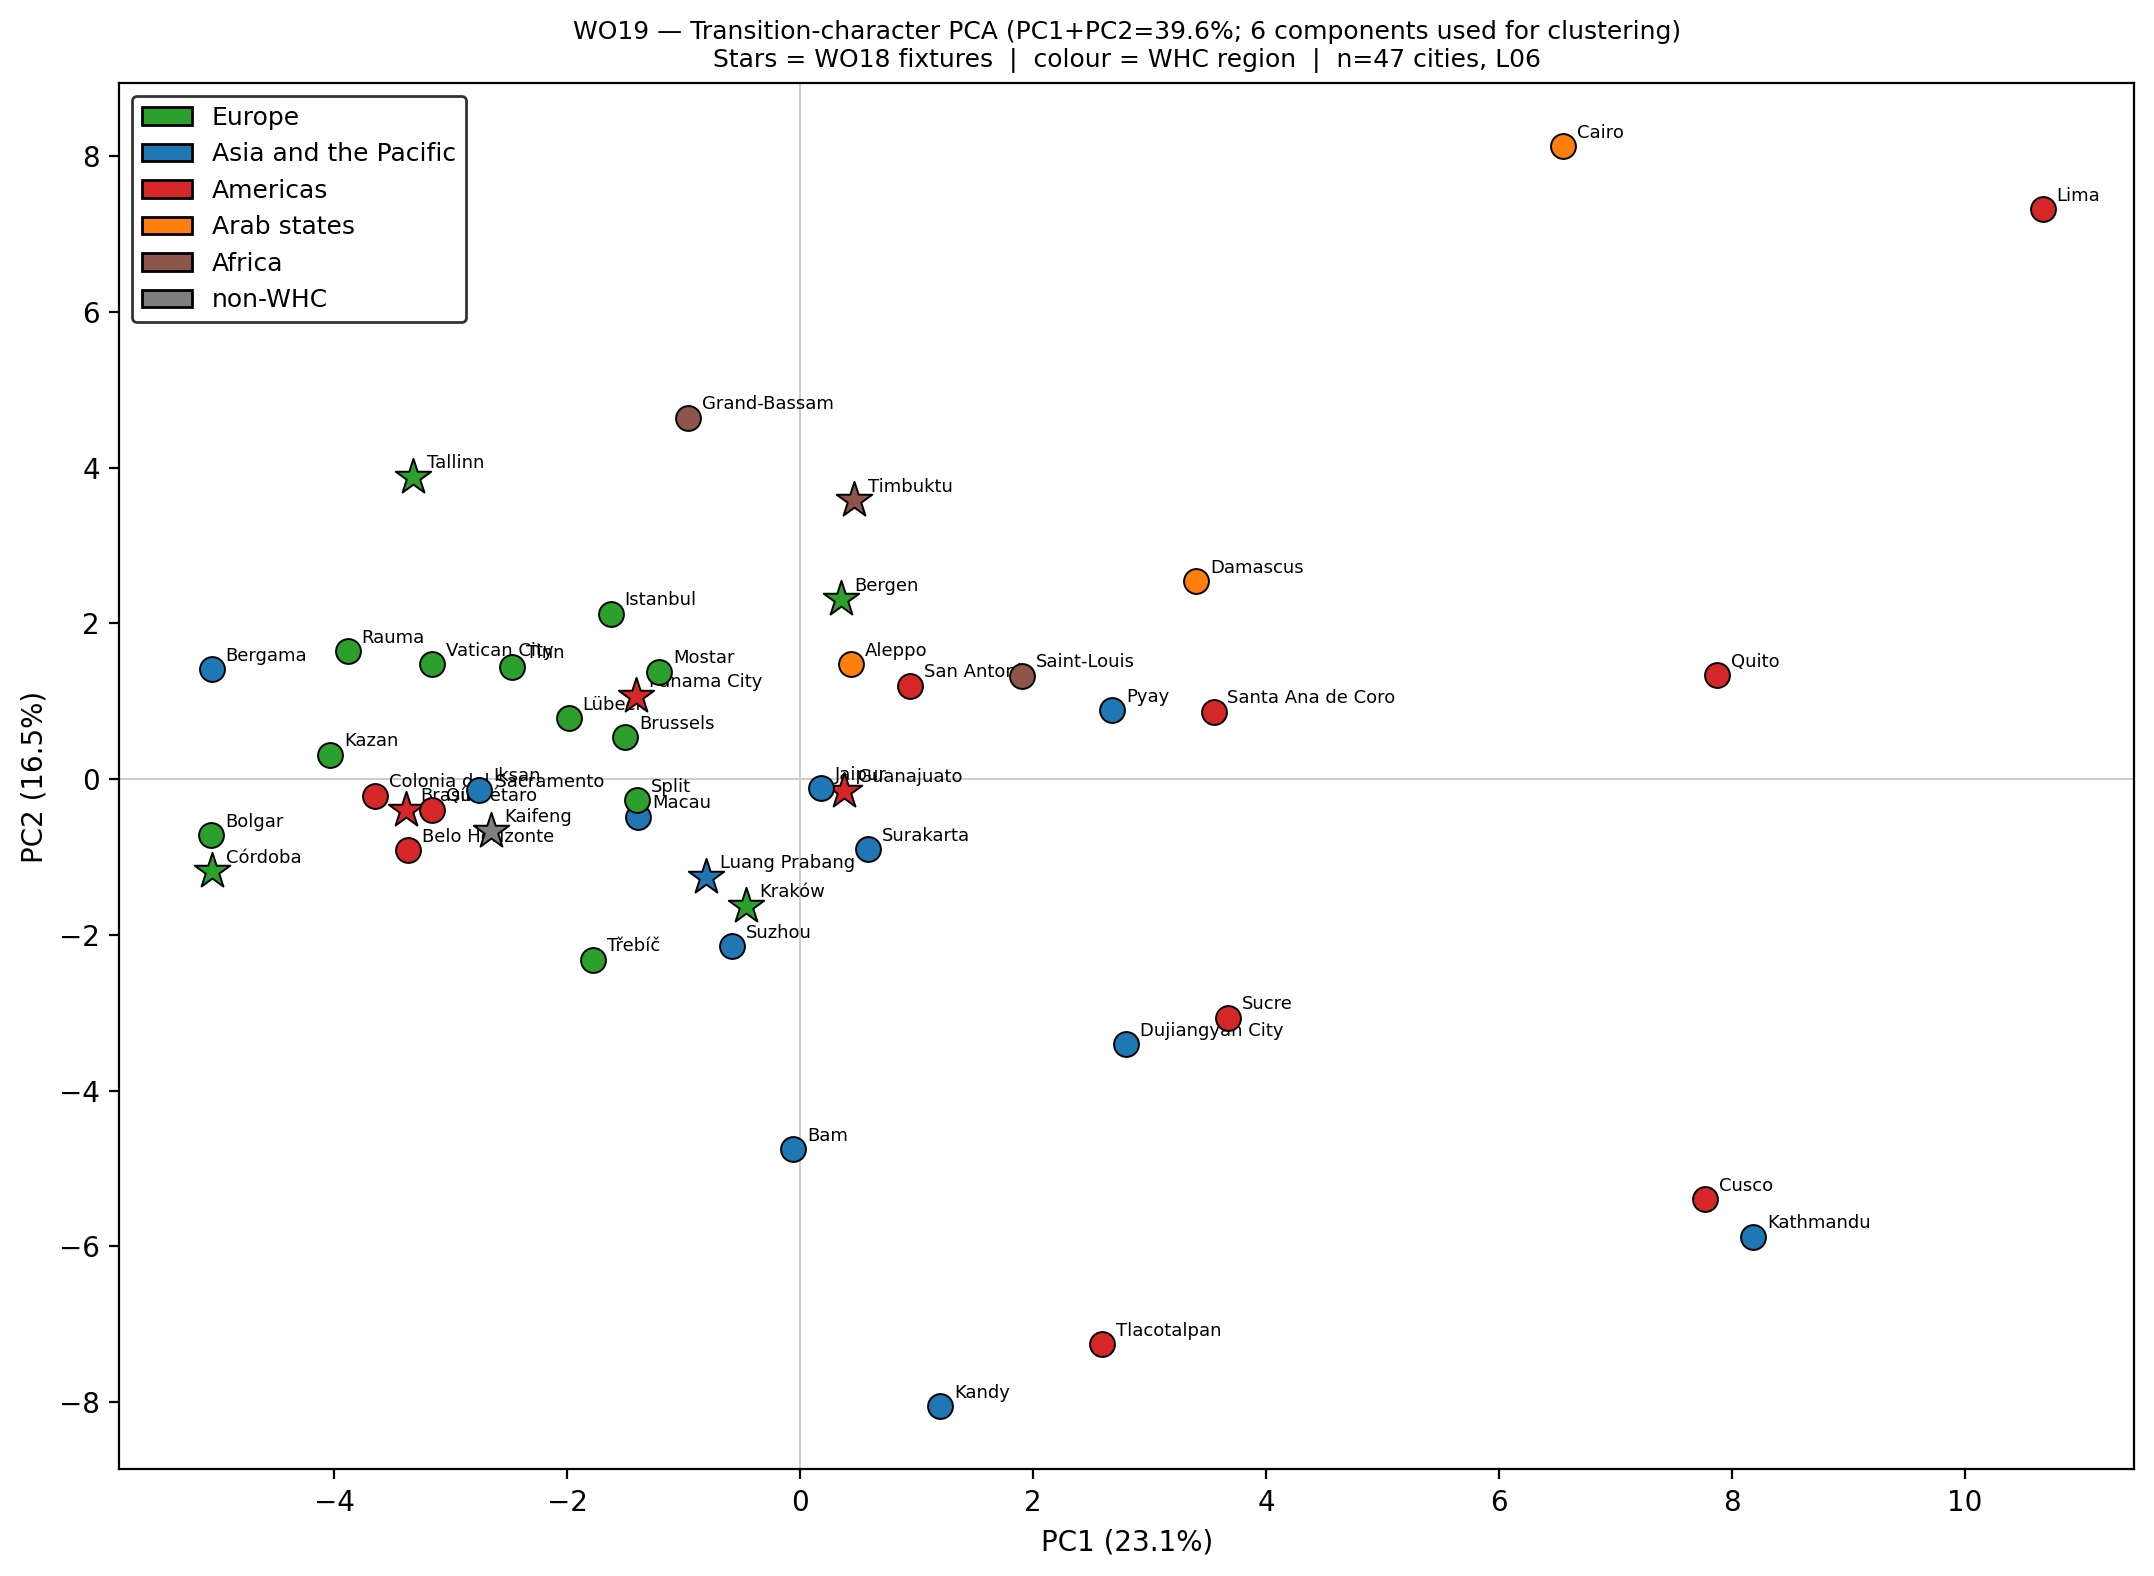

In [16]:
# Cell 9 — PCA on comparator vectors: determine n_components, scree plot, 2D projection
#
# WO18 found 44.4% in 2 components — 2-D is a slice.
# Select n_components = max(3, first k where cumulative variance ≥ 70%).
# X_pca_all (n × n_components) is used for clustering in Cell 10.

pca_full   = SKPCA(n_components=min(len(cities)-1, len(feat_cols)), random_state=42)
pca_full.fit(X_std)
cumvar     = np.cumsum(pca_full.explained_variance_ratio_)

n_for_70     = int(np.argmax(cumvar >= 0.70)) + 1
n_components = max(3, n_for_70)
print('Variance by component (first 15):')
for i, (v, cv) in enumerate(zip(pca_full.explained_variance_ratio_[:15], cumvar[:15]), 1):
    marker = ' ← chosen cutoff' if i == n_components else ''
    print(f'  PC{i:2d}: {v*100:5.1f}%  cumul={cv*100:5.1f}%{marker}')
print(f'\nUsing {n_components} components (≥70% cumvar requires {n_for_70}; min=3).')

pca       = SKPCA(n_components=n_components, random_state=42)
X_pca_all = pca.fit_transform(X_std)
var_exp   = pca.explained_variance_ratio_
print(f'Variance captured: {sum(var_exp)*100:.1f}% across {n_components} components')

# --- Scree plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')
ks = np.arange(1, min(len(cumvar)+1, 21))
axes[0].bar(ks, pca_full.explained_variance_ratio_[:20]*100, color='#4e9af1', edgecolor='black', linewidth=0.5)
axes[0].axvline(n_components + 0.5, color='red', linewidth=1.5, linestyle='--', label=f'chosen k={n_components}')
axes[0].set_xlabel('Component', color='black'); axes[0].set_ylabel('% variance', color='black')
axes[0].set_title('Scree (first 20 components)', color='black'); axes[0].tick_params(colors='black')
leg = axes[0].legend(facecolor='white', edgecolor='black')
for t in leg.get_texts(): t.set_color('black')
axes[1].plot(ks, cumvar[:20]*100, 'o-', color='#e07b39', linewidth=2)
axes[1].axhline(70, color='gray', linewidth=1, linestyle=':'); axes[1].axhline(80, color='gray', linewidth=1, linestyle=':')
axes[1].axvline(n_components + 0.5, color='red', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Components', color='black'); axes[1].set_ylabel('Cumulative %', color='black')
axes[1].set_title('Cumulative variance', color='black'); axes[1].tick_params(colors='black')
fig.suptitle('WO19 — PCA on transition-character comparator vectors', color='black', fontsize=11)
scree_path = OUT / 'wo19_pca_scree.png'
fig.savefig(scree_path, dpi=200, bbox_inches='tight', facecolor='white'); plt.close(fig)
display(IPImage(str(scree_path)))

# --- 2D projection (PC1 vs PC2, coloured by region) ---
region_colors = {
    'Europe':               '#2ca02c',
    'Asia and the Pacific': '#1f77b4',
    'Americas':             '#d62728',
    'Arab states':          '#ff7f0e',
    'Africa':               '#8c564b',
    'non-WHC':              '#7f7f7f',
}

fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

for i, city in enumerate(cities):
    region  = comp_df.loc[comp_df['city'] == city, 'region'].values[0]
    is_wo18 = comp_df.loc[comp_df['city'] == city, 'wo18'].values[0]
    color   = region_colors.get(region, '#7f7f7f') if city != 'Kaifeng' else '#7f7f7f'
    marker  = '*' if is_wo18 else 'o'
    size    = 180 if is_wo18 else 80
    ax.scatter(X_pca_all[i, 0], X_pca_all[i, 1], c=color, s=size,
               marker=marker, edgecolors='black', linewidths=0.7, zorder=5)
    ax.annotate(city, (X_pca_all[i, 0], X_pca_all[i, 1]),
                xytext=(5, 3), textcoords='offset points', fontsize=6.5, color='black')

ax.axhline(0, color='#cccccc', linewidth=0.7, zorder=1)
ax.axvline(0, color='#cccccc', linewidth=0.7, zorder=1)
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)', color='black')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)', color='black')
ax.tick_params(colors='black')
for spine in ax.spines.values(): spine.set_edgecolor('black')

legend_patches = [mpatches.Patch(facecolor=c, edgecolor='black', label=r)
                  for r, c in region_colors.items()]
leg = ax.legend(handles=legend_patches, fontsize=9, facecolor='white',
                edgecolor='black', loc='upper left')
for t in leg.get_texts(): t.set_color('black')

ax.set_title(
    f'WO19 — Transition-character PCA (PC1+PC2={sum(var_exp[:2])*100:.1f}%; '
    f'{n_components} components used for clustering)\n'
    f'Stars = WO18 fixtures  |  colour = WHC region  |  n={len(cities)} cities, L06',
    color='black', fontsize=9)
pca_path = OUT / 'wo19_pca_2d.png'
fig.savefig(pca_path, dpi=200, bbox_inches='tight', facecolor='white'); plt.close(fig)
display(IPImage(str(pca_path)))


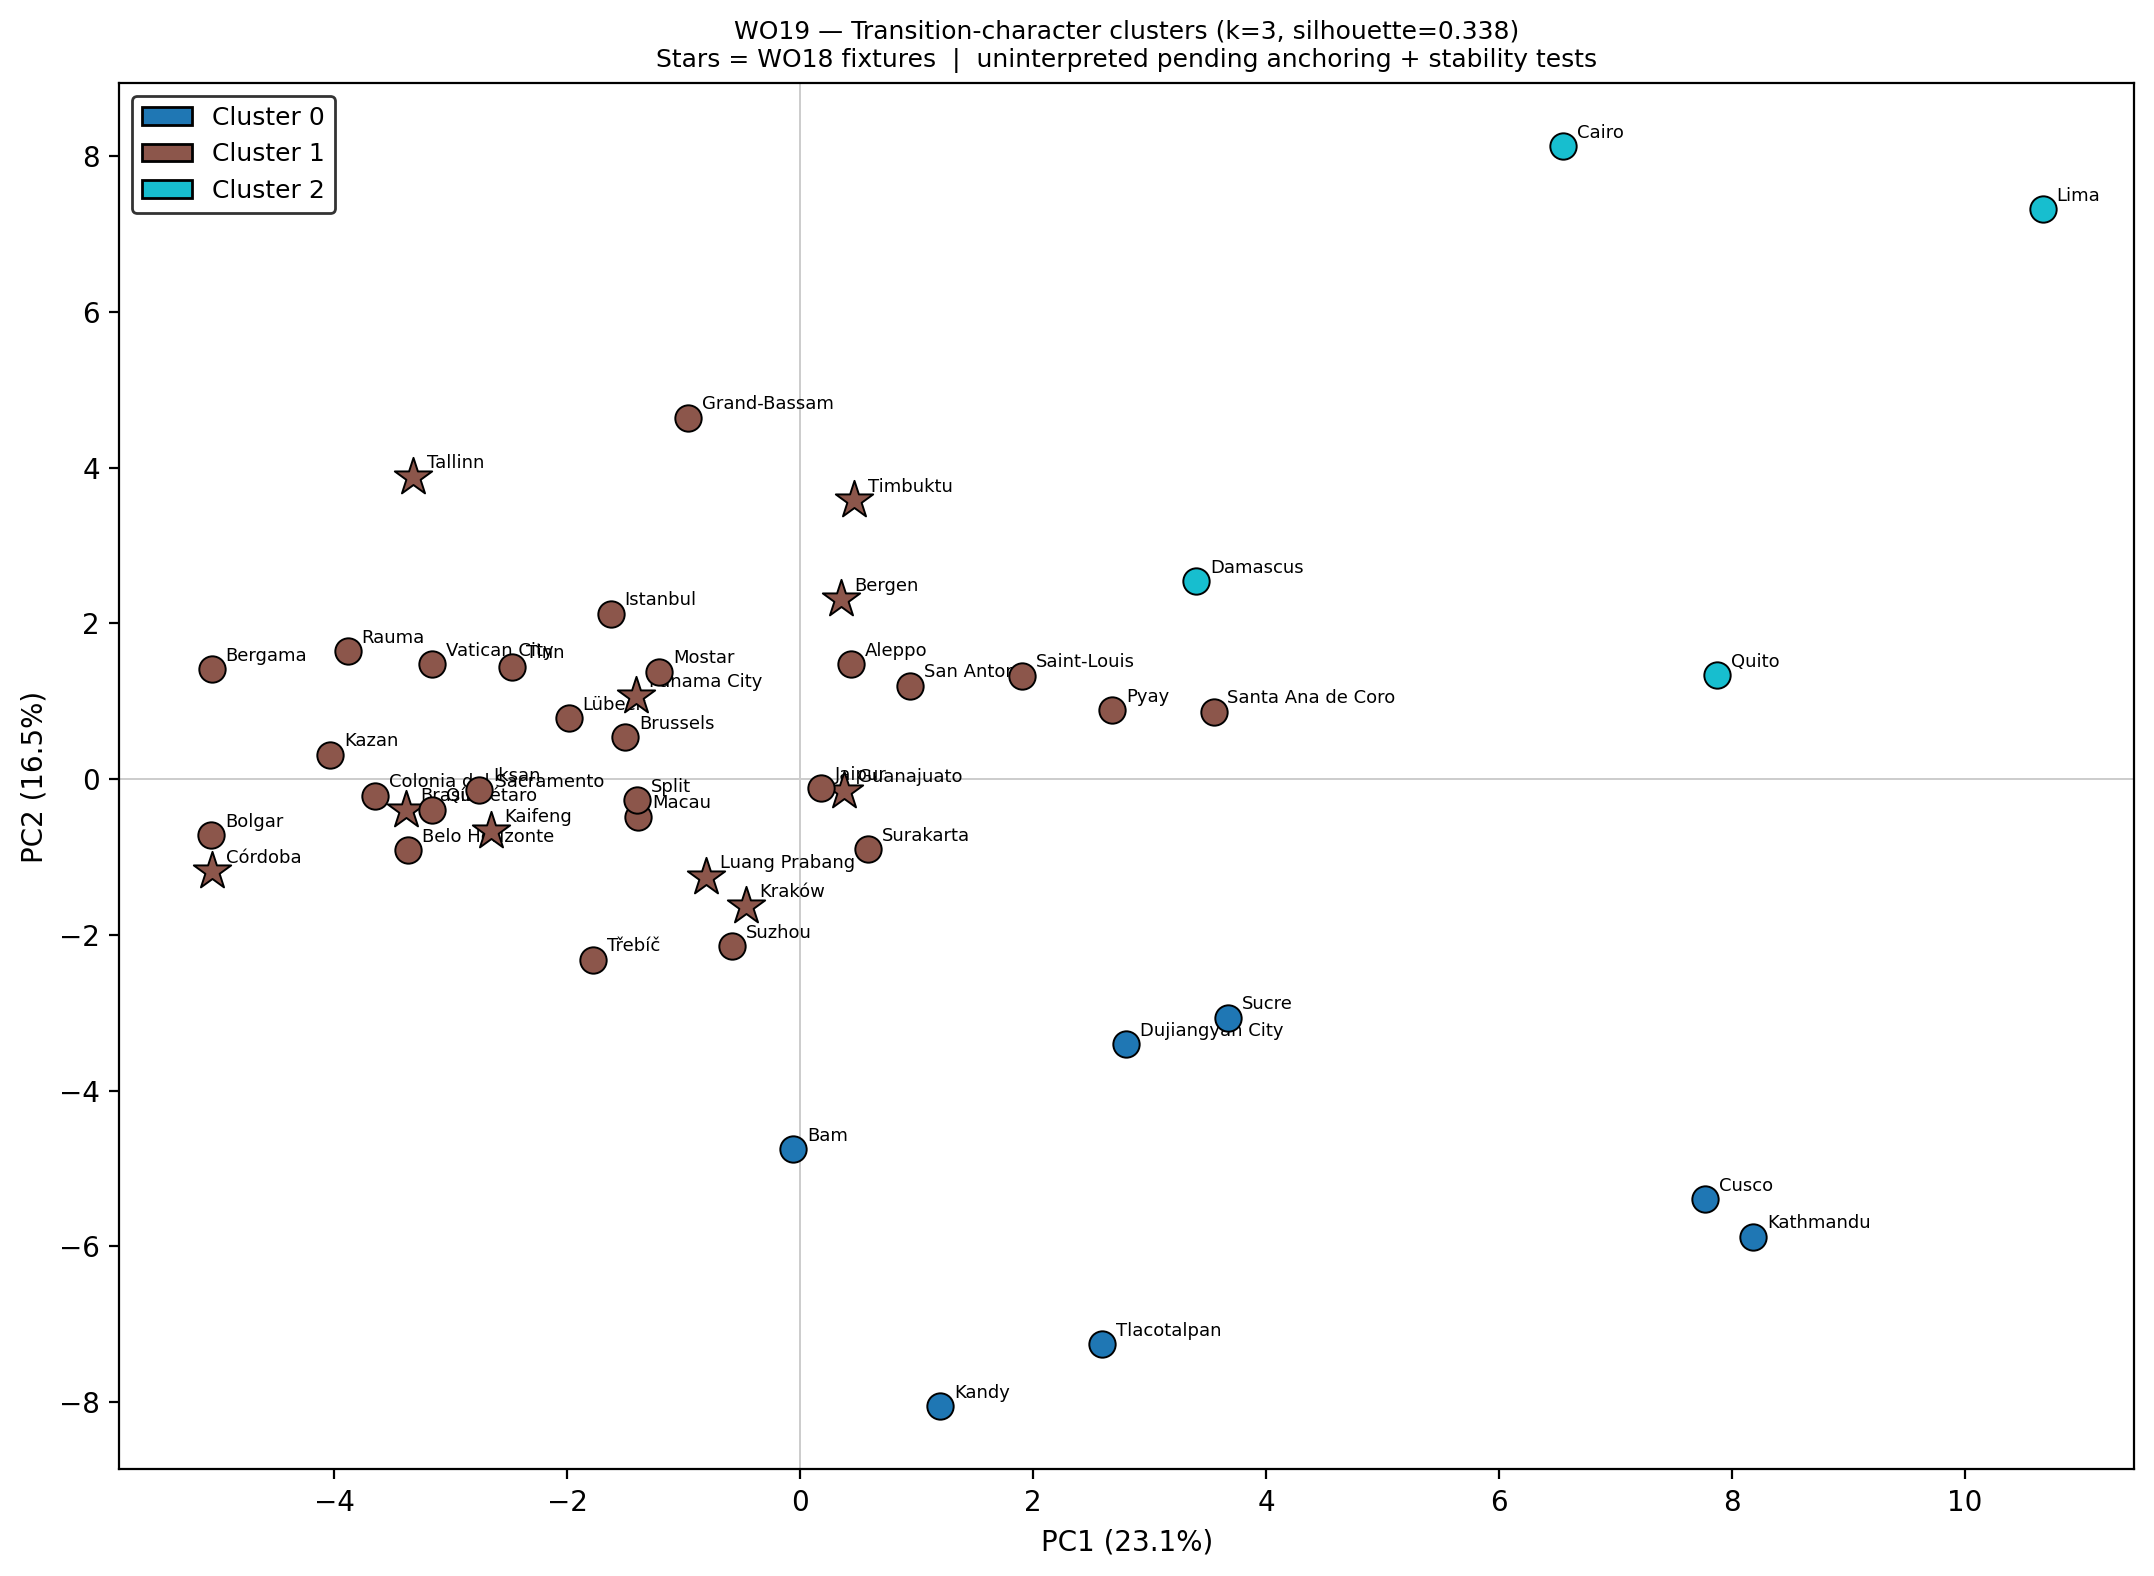

In [17]:
# Cell 10 — clustering on ≥3 PCA components
#
# Use X_pca_all (n × n_components from Cell 9) for k-means.
# Choose k via silhouette score over k=2..8; report cluster assignments.
# DO NOT interpret the clusters here — Parts 3–4 gate interpretation.

print(f'Clustering in {n_components}-component PCA space (n={len(cities)} cities).')
print()

sil_scores = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_pca_all)
    sil = silhouette_score(X_pca_all, labels)
    sil_scores[k] = round(sil, 4)
    print(f'  k={k}: silhouette={sil:.4f}')

optimal_k = max(sil_scores, key=sil_scores.get)
print(f'\nOptimal k by silhouette: {optimal_k} (score={sil_scores[optimal_k]:.4f})')
print('(Verify this is not k=2 bias — inspect the plot before accepting.)')

km_tc          = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
cluster_labels = km_tc.fit_predict(X_pca_all)
comp_df['tc_cluster'] = cluster_labels

print(f'\nCluster assignments (k={optimal_k}; held uninterpreted until Cells 11–12):')
for k in range(optimal_k):
    members = comp_df[comp_df['tc_cluster'] == k]['city'].tolist()
    print(f'  Cluster {k} (n={len(members)}): {", ".join(members)}')

cluster_palette = plt.cm.tab10(np.linspace(0, 1, optimal_k))

fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

for i, city in enumerate(cities):
    k       = cluster_labels[i]
    color   = cluster_palette[k]
    is_wo18 = comp_df.loc[comp_df['city'] == city, 'wo18'].values[0]
    marker  = '*' if is_wo18 else 'o'
    size    = 200 if is_wo18 else 90
    ax.scatter(X_pca_all[i, 0], X_pca_all[i, 1], c=[color], s=size,
               marker=marker, edgecolors='black', linewidths=0.7, zorder=5)
    ax.annotate(city, (X_pca_all[i, 0], X_pca_all[i, 1]),
                xytext=(5, 3), textcoords='offset points', fontsize=6.5, color='black')

ax.axhline(0, color='#cccccc', linewidth=0.7); ax.axvline(0, color='#cccccc', linewidth=0.7)
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)', color='black')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)', color='black')
ax.tick_params(colors='black')
for spine in ax.spines.values(): spine.set_edgecolor('black')

labels_patches = [mpatches.Patch(facecolor=cluster_palette[k], edgecolor='black',
                                 label=f'Cluster {k}') for k in range(optimal_k)]
leg = ax.legend(handles=labels_patches, fontsize=9, facecolor='white', edgecolor='black')
for t in leg.get_texts(): t.set_color('black')

ax.set_title(
    f'WO19 — Transition-character clusters (k={optimal_k}, silhouette={sil_scores[optimal_k]:.3f})\n'
    f'Stars = WO18 fixtures  |  uninterpreted pending anchoring + stability tests',
    color='black', fontsize=9)
cluster_path = OUT / 'wo19_clusters.png'
fig.savefig(cluster_path, dpi=200, bbox_inches='tight', facecolor='white'); plt.close(fig)
display(IPImage(str(cluster_path)))


In [19]:
# Cell 11 — (a) anchoring test
#
# Does the clustering align with any external covariate it never saw?
# Covariates tested: region, drain_type, size_class, dis_tier, climate_zone.
# Per covariate: cross-tab cluster × covariate + Cramér's V.
#
# Read: alignment with a physical covariate = anchored to the world.
# No alignment with anything = partition only the instrument sees
# (novel discovery or artifact — cannot resolve without more data).

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, _, _ = chi2_contingency(ct)
    n = int(ct.sum().sum())
    r, k = ct.shape
    phi2 = chi2 / n
    v = np.sqrt(phi2 / max(min(k-1, r-1), 1))
    return round(v, 4), round(p, 4)

# Build combined df: cluster label + covariates (only cities in comparator)
cluster_series = pd.Series(cluster_labels, index=cities, name='tc_cluster')
anchoring_df   = COV_DF.loc[[c for c in cities if c in COV_DF.index]].copy()
anchoring_df['tc_cluster'] = cluster_series.loc[anchoring_df.index].astype(str)

COVARIATES = [
    ('region',        'Region (WHC classification)'),
    ('drain_type',    'Drainage type (exo / endo / terminal)'),
    ('size_class',    'Basin size class'),
    ('dis_tier',      'Discharge tier'),
    ('climate_zone',  'Climate zone (lu_cls genz_name)'),
]

print(f'Anchoring test — cluster × covariate (k={optimal_k}, n={len(anchoring_df)} cities)')
print(f'{"Covariate":<35} {"Cramér V":>10}  {"p":>8}  Read')
print('-' * 75)

results_anchor = []
for col, label in COVARIATES:
    v, p = cramers_v(anchoring_df['tc_cluster'], anchoring_df[col].astype(str))
    if   v >= 0.30: read = 'moderate-strong association'
    elif v >= 0.15: read = 'weak-moderate association'
    else:           read = 'negligible association'
    results_anchor.append({'covariate': col, 'label': label, 'cramers_v': v, 'p': p, 'read': read})
    print(f'  {label:<33}  V={v:6.4f}  p={p:6.4f}  {read}')

print()
print('Cross-tabulations:')
for col, label in COVARIATES:
    ct = pd.crosstab(anchoring_df['tc_cluster'], anchoring_df[col].astype(str))
    print(f'\n  {label}:')
    print(ct.to_string())


Anchoring test — cluster × covariate (k=3, n=47 cities)
Covariate                             Cramér V         p  Read
---------------------------------------------------------------------------
  Region (WHC classification)        V=0.5020  p=0.0026  moderate-strong association
  Drainage type (exo / endo / terminal)  V=0.3340  p=0.0330  moderate-strong association
  Basin size class                   V=0.3048  p=0.0681  moderate-strong association
  Discharge tier                     V=0.3733  p=0.0415  moderate-strong association
  Climate zone (lu_cls genz_name)    V=0.5468  p=0.2556  moderate-strong association

Cross-tabulations:

  Region (WHC classification):
region      Africa  Americas  Arab states  Asia and the Pacific  Europe
tc_cluster                                                             
0                0         3            0                     4       0
1                3         8            1                     9      15
2                0         2        

In [21]:
# Cell 12 — (b) stability test
#
# Two perturbations:
#   Part A — sample: drop ~20% of non-WO18 cities, re-cluster N=200 times;
#             track co-assignment frequency for each city pair.
#   Part B — representation: re-cluster using sign_pattern binary vector
#             instead of mean_abs+max_abs; report Adjusted Rand Index vs main.
#
# Read:
#   Stable across both → real density structure.
#   Reshuffles under sample drop → method artifact; specific groups are luck.
#   Differs sharply by representation → depends on a setup coin-flip.

np.random.seed(42)
N_BOOT    = 200
DROP_FRAC = 0.20

wo18_set   = set(comp_df[comp_df['wo18']]['city'])
new_cities = [c for c in cities if c not in wo18_set]
n_drop     = max(1, int(len(new_cities) * DROP_FRAC))

print(f'Bootstrap stability: N={N_BOOT}, drop {n_drop}/{len(new_cities)} non-WO18 cities each run.')

city_idx   = {c: i for i, c in enumerate(cities)}
coassign   = np.zeros((len(cities), len(cities)), dtype=float)
coassign_n = np.zeros((len(cities), len(cities)), dtype=int)

for boot in range(N_BOOT):
    drop     = set(np.random.choice(new_cities, n_drop, replace=False))
    keep     = [c for c in cities if c not in drop]
    idx_keep = [city_idx[c] for c in keep]
    X_boot   = X_pca_all[idx_keep]
    lbl_boot = KMeans(n_clusters=optimal_k, random_state=boot, n_init=10).fit_predict(X_boot)
    for ii, ci in enumerate(keep):
        for jj, cj in enumerate(keep):
            gi, gj = city_idx[ci], city_idx[cj]
            coassign_n[gi, gj] += 1
            if lbl_boot[ii] == lbl_boot[jj]:
                coassign[gi, gj] += 1

with np.errstate(invalid='ignore'):
    coassign_freq = np.where(coassign_n > 0, coassign / coassign_n, np.nan)

freq_df = pd.DataFrame(coassign_freq, index=cities, columns=cities).round(3)
freq_df.to_csv(OUT / 'wo19_bootstrap_coassignment.tsv', sep='\t')

wo18_list = sorted(wo18_set)
pairs = [(c1, c2) for i, c1 in enumerate(wo18_list) for c2 in wo18_list[i+1:]]
freqs = [freq_df.loc[c1, c2] for c1, c2 in pairs if not np.isnan(freq_df.loc[c1, c2])]
print(f'\nWO18 pair co-assignment (how often WO18 fixtures cluster together):')
if freqs:
    print(f'  min={min(freqs):.3f}  max={max(freqs):.3f}  mean={np.mean(freqs):.3f}')

print('\nMost stable pairs (co-assignment freq > 0.80):')
stable = []
for i, ci in enumerate(cities):
    for j, cj in enumerate(cities):
        if j <= i:
            continue
        f = coassign_freq[i, j]
        if not np.isnan(f) and f > 0.80:
            stable.append((ci, cj, f))
stable.sort(key=lambda x: -x[2])
for ci, cj, f in stable[:20]:
    print(f'  {ci:22s} ↔ {cj:22s}  freq={f:.3f}')
if not stable:
    print('  None — no pairs co-assign > 80% of runs.')

# --- Part B: representation swap ---
print('\n--- Part B: representation swap (sign_pattern binary vector) ---')

sp_rows = []
for name in included:
    fx      = next(f for f in FIXTURES if f['name'] == name)
    char_df = RESULTS[name]['char_df'].set_index('variable')
    row = {'city': name}
    for var in common_vars:
        if var in char_df.index:
            sp = char_df.loc[var, 'sign_pattern']
            row[f'{var}_sp'] = 1 if sp == 'all+' else (-1 if sp == 'all-' else 0)
        else:
            row[f'{var}_sp'] = 0
    sp_rows.append(row)

sp_df   = pd.DataFrame(sp_rows)
sp_cols = [c for c in sp_df.columns if c != 'city']
X_sp    = StandardScaler().fit_transform(sp_df[sp_cols].values)

sp_labels = KMeans(n_clusters=optimal_k, random_state=42, n_init=20).fit_predict(X_sp)
ari = adjusted_rand_score(cluster_labels, sp_labels)
print(f'Adjusted Rand Index (main vs sign_pattern swap): ARI={ari:.4f}')
if   ari >= 0.60: read = 'broadly preserved — clustering not representation-dependent'
elif ari >= 0.30: read = 'partial agreement — some representation sensitivity'
else:             read = 'low agreement — clustering depends heavily on representation choice'
print(f'Read: {read}')

print('\nSwap cluster assignments:')
for k in range(optimal_k):
    members = sp_df[sp_labels == k]['city'].tolist()
    print(f'  Cluster {k} (n={len(members)}): {", ".join(members)}')



WO18 pair co-assignment (how often WO18 fixtures cluster together):
  min=0.640  max=0.995  mean=0.874

Most stable pairs (co-assignment freq > 0.80):
  Bam                    ↔ Kandy                   freq=1.000
  Belo Horizonte         ↔ Querétaro               freq=1.000
  Bergama                ↔ Panama City             freq=1.000
  Bergama                ↔ Rauma                   freq=1.000
  Bergama                ↔ Tinn                    freq=1.000
  Bolgar                 ↔ Colonia del Sacramento  freq=1.000
  Bolgar                 ↔ Kazan                   freq=1.000
  Colonia del Sacramento ↔ Kazan                   freq=1.000
  Istanbul               ↔ Kaifeng                 freq=1.000
  Istanbul               ↔ Vatican City            freq=1.000
  Jaipur                 ↔ Kraków                  freq=1.000
  Kaifeng                ↔ Vatican City            freq=1.000
  Kandy                  ↔ Tlacotalpan             freq=1.000
  Kazan                  ↔ Split          

In [22]:
# Cell 13 — close connection + AF.WO19.n findings
#
# Summary of the three test reads before any cluster interpretation.
# Fill in the actual verdicts after running Cells 11–12.

conn.close()
print('Connection closed.')
print()
print('=== WO19 — three-test verdict ===')
print()
print('(a) Anchoring — does the clustering align with external covariates?')
print('    [fill in from Cell 11 Cramér V results]')
print('    → ANCHORED / UNANCHORED / PARTIAL')
print()
print('(b) Stability — does clustering survive 20% sample drop + representation swap?')
print('    Bootstrap: [fill in co-assignment min/max for main pairs]')
print('    Swap ARI:  [fill in from Cell 12]')
print('    → STABLE / UNSTABLE / REPRESENTATION-DEPENDENT')
print()
print('(c) Cultural probe — DEFERRED (function attributes not available as structured data).')
print()
print('---')
print('Scope of all conclusions: L06, single first-order ring, bands A–E, static.')
print()
print('AF.WO19 findings to add to areas_findings.md:')
print('  AF.WO19.1 [method] — variable intersection at n=50: [n vars; shift from 29 if any]')
print('  AF.WO19.2 [method] — PCA depth: [n_components chosen; cumvar]')
print('  AF.WO19.3 [method] — (a) anchoring: [which covariates tracked, Cramér V]')
print('  AF.WO19.4 [method] — (b) stability: [bootstrap verdict; ARI for swap]')
print('  AF.WO19.5 [method] — overall branch verdict: [anchored+stable / unstable / etc.]')


Connection closed.

=== WO19 — three-test verdict ===

(a) Anchoring — does the clustering align with external covariates?
    [fill in from Cell 11 Cramér V results]
    → ANCHORED / UNANCHORED / PARTIAL

(b) Stability — does clustering survive 20% sample drop + representation swap?
    Bootstrap: [fill in co-assignment min/max for main pairs]
    Swap ARI:  [fill in from Cell 12]
    → STABLE / UNSTABLE / REPRESENTATION-DEPENDENT

(c) Cultural probe — DEFERRED (function attributes not available as structured data).

---
Scope of all conclusions: L06, single first-order ring, bands A–E, static.

AF.WO19 findings to add to areas_findings.md:
  AF.WO19.1 [method] — variable intersection at n=50: [n vars; shift from 29 if any]
  AF.WO19.2 [method] — PCA depth: [n_components chosen; cumvar]
  AF.WO19.3 [method] — (a) anchoring: [which covariates tracked, Cramér V]
  AF.WO19.4 [method] — (b) stability: [bootstrap verdict; ARI for swap]
  AF.WO19.5 [method] — overall branch verdict: [anchor